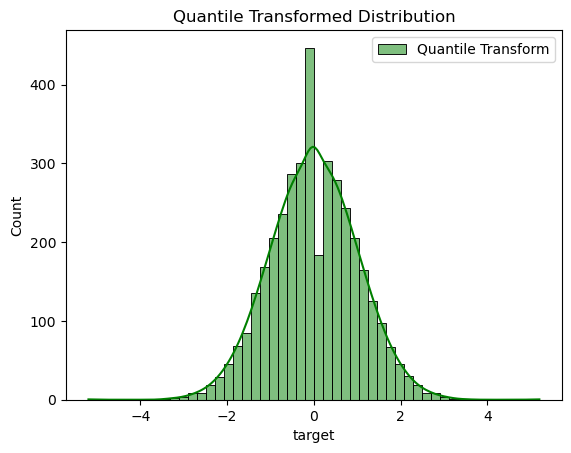

In [3]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer, AutoConfig, AutoModel
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = 'processed_datasets/cytotoxicity_data.csv'
df = pd.read_csv(dataset_path)
df['target'] = df['CC50/IC50/EC50, mM'].apply(lambda x: -np.log10(x))
df['target'] = QuantileTransformer(output_distribution='normal').fit_transform(df['target'].values.reshape(-1, 1))

sns.histplot(df['target'], bins=50, kde=True, color='green', label='Quantile Transform')
plt.title('Quantile Transformed Distribution')
plt.legend()
plt.show()

In [12]:
def featurize_smi_ted(smiles_list):
    config = AutoConfig.from_pretrained("bisectgroup/materials-smi-ted-fork")
    tokenizer = AutoTokenizer.from_pretrained("bisectgroup/materials-smi-ted-fork")
    model = AutoModel.from_pretrained("bisectgroup/materials-smi-ted-fork")

    model.smi_ted.tokenizer = tokenizer
    model.smi_ted.set_padding_idx_from_tokenizer()
    encoder_outputs = []
    with torch.no_grad():
        for smiles in tqdm(smiles_list, desc="Encoding SMILES"):
            encoder_outputs.append(model.encode(smiles))
            # break  # Remove this break to process all SMILES

    # If all encoder_outputs are tensors of the same shape, stack them
    if len(encoder_outputs) > 0 and isinstance(encoder_outputs[0], torch.Tensor):
        encoder_outputs = torch.stack(encoder_outputs)
        print(encoder_outputs.shape)
        return encoder_outputs.numpy()
    else:
        return encoder_outputs

smi_ted_features = featurize_smi_ted(df['Canonical SMILES'].tolist())


Encoding SMILES: 100%|██████████| 3837/3837 [03:38<00:00, 17.53it/s]

torch.Size([3837, 1, 768])


In [14]:
chemberta = AutoModelForMaskedLM.from_pretrained("DeepChem/ChemBERTa-77M-MTR")
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR")

def featurize_ChemBERTa(smiles_list, padding=True):
    embeddings_cls = torch.zeros(len(smiles_list), 600)
    embeddings_mean = torch.zeros(len(smiles_list), 600)

    with torch.no_grad():
        for i, smiles in enumerate(tqdm(smiles_list)):
            encoded_input = tokenizer(smiles, return_tensors="pt",padding=padding,truncation=True)
            model_output = chemberta(**encoded_input)
            
            embedding = model_output[0][::,0,::]
            embeddings_cls[i] = embedding
            
            embedding = torch.mean(model_output[0],1)
            embeddings_mean[i] = embedding
            
    return embeddings_cls.numpy(), embeddings_mean.numpy()

# Featurize the dataset
X_cls, X_mean = featurize_ChemBERTa(df['Canonical SMILES'].tolist(), padding=True)

# save the dataset as parquet
df['X_cls'] = list(X_cls)
df['X_mean'] = list(X_mean)
# Flatten each array in X_smi_ted to 1D before storing
df['X_smi_ted'] = [arr.flatten().tolist() for arr in smi_ted_features]

# using il_classes as input
il_classes = df['filename'].unique().tolist()
print(f"Number of unique il types: {len(il_classes)}")

# get dummies for this
il_dummies = pd.get_dummies(df['filename'], prefix='il', dtype=float)

# Assign the one-hot encoded vectors as a list to a new column
df['il_type'] = il_dummies.values.tolist()

display(df.head())
df.to_parquet("ct.parquet", index=False)

Some weights of RobertaForMaskedLM were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['lm_head.bias', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 3837/3837 [00:13<00:00, 291.18it/s]


Number of unique il types: 17


,Canonical SMILES,"CC50/IC50/EC50, mM",filename,target,X_cls,X_mean,X_smi_ted,il_type
0,Oc1ccc(C[P+](c2cccs2)(c2cccs2)c2cccs2)[nH+]c1C...,0.2655,polycharged.csv,-0.337105,"[0.11201892, 0.0, -0.3920954, -0.26561418, -0....","[0.020525262, 0.0, -0.16850275, -0.42897144, -...","[0.48589175939559937, -0.6901811361312866, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CCCC[P+](CCCC)(CCCC)Cc1ccc(O)c(C[P+](CCCC)(CCC...,1.2410,polycharged.csv,-0.658023,"[0.27872, 0.0, 0.015050509, 0.31996512, -1.010...","[-0.4141142, 0.0, 0.3669449, -0.114338286, 0.1...","[0.40258318185806274, -0.571060061454773, 0.06...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Oc1ccc(C[P+](c2ccccc2)(c2ccccc2)c2ccccc2)[nH+]...,0.0255,polycharged.csv,0.388497,"[0.80310357, 0.0, -0.44022238, -0.4134048, -0....","[0.13906911, 0.0, -0.020954566, -0.3940836, 0....","[0.43915247917175293, -0.5943257808685303, 0.1...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Cc1ccc([P+](Cc2ccc(O)c(C[P+](c3ccc(C)cc3)(c3cc...,0.0300,polycharged.csv,0.358833,"[0.85204875, 0.0, -0.5947919, -0.24078058, -0....","[0.27120024, 0.0, 0.012193584, -0.39439833, 0....","[0.5145204067230225, -0.5056378245353699, 0.10...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Cc1ccc([P+](Cc2ccc(O)c(C[P+](c3ccc(C)cc3)(c3cc...,0.0300,polycharged.csv,0.358833,"[0.85204875, 0.0, -0.5947919, -0.24078058, -0....","[0.27120024, 0.0, 0.012193584, -0.39439833, 0....","[0.5145204067230225, -0.5056378245353699, 0.10...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from rdkit import Chem

class CTDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)
    
    def mol_to_graph(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")

        edge_index = []
        node_features = []
        edge_features = []

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            bond_type = bond.GetBondTypeAsDouble()  # 1.0, 2.0, 3.0, 1.5 (aromatic)
            is_conjugated = bond.GetIsConjugated()
            is_in_ring = bond.IsInRing()

            edge_feat = [bond_type, float(is_conjugated), float(is_in_ring)]

            # Add both directions
            edge_index.append((i, j))
            edge_index.append((j, i))
            edge_features.append(edge_feat)
            edge_features.append(edge_feat)

        # one hot encoding of atom types
        for atom in mol.GetAtoms():
            atom_type = atom.GetAtomicNum()
            aromatic = atom.GetIsAromatic()
            formal_charge = atom.GetFormalCharge()
            hybridization = int(atom.GetHybridization())
            degree = atom.GetDegree()
            valence = atom.GetTotalValence()

            node_features.append([atom_type, aromatic, formal_charge, hybridization, degree, valence])  

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
        x = torch.tensor(node_features, dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # fetch graph data
        smiles = row['Canonical SMILES']
        graph_data = self.mol_to_graph(smiles)

        # Get cls and mean embeddings
        cls_embedding = row['X_cls']
        mean_embedding = row['X_mean']
        cls_embedding = torch.tensor(cls_embedding, dtype=torch.float)
        mean_embedding = torch.tensor(mean_embedding, dtype=torch.float)
        il_type = torch.tensor(row['il_type'], dtype=torch.float)

        # Get labels 
        label = torch.tensor(row['target'], dtype=torch.float)

        return graph_data, cls_embedding, mean_embedding, il_type, label

def main():
    dataset_path = "./ct.parquet"
    df = pd.read_parquet(dataset_path)

    df['X_cls'] = df['X_cls'].apply(lambda x: np.array(x))
    df['X_mean'] = df['X_mean'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = CTDataset(df)
    print("node feature dims", dataset[0][0].x.shape[1])
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # sample one datapoint from dataset and print node feat dims
    for graph_data, cls_embed, mean_embed, il_type, labels in dataloader:
        print(f"Graph data: {graph_data}")
        print(f"CLS embedding shape: {cls_embed.shape}")
        print(f"Mean embedding shape: {mean_embed.shape}")
        print(f"IL Type shape: {il_type.shape}")
        print(f"Labels shape: {labels.shape}")
        break

if __name__ == "__main__":
    main()

node feature dims 6
Graph data: DataBatch(x=[1164, 6], edge_index=[2, 2322], edge_attr=[2322, 3], batch=[1164], ptr=[33])
CLS embedding shape: torch.Size([32, 600])
Mean embedding shape: torch.Size([32, 600])
IL Type shape: torch.Size([32, 17])
Labels shape: torch.Size([32])


In [ ]:
import torch 
import torch.nn as nn
from torch_geometric.nn import GATConv, GINConv, global_mean_pool, global_add_pool, global_max_pool

class GAT(nn.Module):
    # captures connectivity importances
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)  # Dropout for regularization
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)  # Dropout for regularization
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = nn.GELU()(x)
        return x
    
class GIN(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim):
        super(GIN, self).__init__()

        # MLP for first GIN layer
        self.mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        # MLP for second GIN layer
        self.mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        self.conv1 = GINConv(self.mlp1)
        self.conv2 = GINConv(self.mlp2)
        self.out_lin = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)

        x = self.conv2(x, edge_index)
        x = nn.GELU()(x)
        x = self.out_lin(x)
        return x
    
class GatedFusion(nn.Module):
    def __init__(self, out_channels, num_branches):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(out_channels, 1),   # score per branch
        )

    def forward(self, x):
        # x: [batch_size, num_branches, out_channels]
        scores = self.gate(x).squeeze(-1)          # [batch_size, num_branches]
        weights = torch.softmax(scores, dim=-1)    # normalize across branches
        out = torch.sum(weights.unsqueeze(-1) * x, dim=1)  # [batch_size, out_channels]
        return out

    
class MLP(nn.Module):
    def __init__(self, in_channels_cls, in_channels_mean, out_channels, hidden_dim=128):
        super(MLP, self).__init__()

        # projection for CLS embeddings
        self.cls_fc = nn.Sequential(
            nn.Linear(in_channels_cls, hidden_dim*4),
            nn.BatchNorm1d(hidden_dim*4),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*4, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU()
        )

        # projection for MEAN embeddings
        self.mean_fc = nn.Sequential(
            nn.Linear(in_channels_mean, hidden_dim*4),
            nn.BatchNorm1d(hidden_dim*4),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim*4, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU()
        )
        # small projection for IL type
        self.il_fc = nn.Sequential(
            nn.Linear(len(il_classes), hidden_dim // 2),
            nn.GELU()
        )

        self.embed_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim//2)
        )
        self.final_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_channels)
        )


    def forward(self, cls_input, mean_input, il_class_input):
        # remove conv unsqueeze stuff: ChemBERTa embeddings are already [B, D]
        cls_out = self.cls_fc(cls_input)
        mean_out = self.mean_fc(mean_input)
        il_out = self.il_fc(il_class_input)

        combined = torch.cat([cls_out, mean_out], dim=1)
        embed_out = self.embed_fc(combined)
        combined_2 = torch.cat([embed_out, il_out], dim=1)  

        out = self.final_fc(combined_2)
        return out

class twoTrackNetwork(nn.Module):

    def __init__(self, in_channels, out_channels, in_channels_cls, in_channels_mean, hidden_dim):
        super(twoTrackNetwork, self).__init__()
        self.gat = GAT(in_channels, out_channels, hidden_dim)
        self.gin = GIN(in_channels, hidden_dim=hidden_dim, out_dim=out_channels)
        # self.mfnet = MFNet(in_channels, out_channels)
        self.mlp = MLP(in_channels_cls, in_channels_mean, out_channels)
        self.pooling_fc = nn.Sequential(
            nn.Linear(out_channels * 6, out_channels),
            nn.GELU(),
        )
        self.branch_fusion = GatedFusion(out_channels, num_branches=4)

        self.final_mlp = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, 1)
        )

    def forward(self, graph_data, cls_embed, mean_embed, il_type):
        # Graph data
        x, edge_index, batch = graph_data.x, graph_data.edge_index, graph_data.batch

        # mfnet_out = self.mfnet(x, edge_index)
        gat_out = self.gat(x, edge_index)
        gin_out = self.gin(x, edge_index)

        # Pooling
        gat_max = global_max_pool(gat_out, batch)
        gin_max = global_max_pool(gin_out, batch)
        gat_add = global_add_pool(gat_out, batch)
        gin_add = global_add_pool(gin_out, batch)
        gat_mean = global_mean_pool(gat_out, batch)
        gin_mean = global_mean_pool(gin_out, batch)

        # Concatenate all pooled features
        pooled = torch.cat([gat_max, gin_max, gat_add, gin_add, gat_mean, gin_mean], dim=1)
        pool_out = self.pooling_fc(pooled)

        embedding_out = self.mlp(cls_embed, mean_embed, il_type)

        # Stack branch outputs shape [batch_size, num_branches, out_channels] for attention
        stacked = torch.stack([
            pool_out,
            embedding_out
        ], dim=1)

        out = self.branch_fusion(stacked)

        # Final prediction head
        out = self.final_mlp(out)

        return out
    
if __name__ == "__main__":
    # Example usage
    model = twoTrackNetwork(in_channels=10, out_channels=32, in_channels_cls=600, in_channels_mean=600, hidden_dim=64)
    print(model)
    print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

twoTrackNetwork(
  (gat): GAT(
    (conv1): GATConv(10, 64, heads=1)
    (conv2): GATConv(64, 64, heads=1)
    (conv3): GATConv(64, 32, heads=1)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (gin): GIN(
    (mlp1): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
    (mlp2): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2

Dataset loaded

Input channels: 600, 600, 6
Output channels: 128
Loaders created. Starting training...

Model parameters: 1110594
epoch: 0, train loss: 0.718, val loss: 0.370
epoch: 1, train loss: 0.386, val loss: 0.268
epoch: 2, train loss: 0.316, val loss: 0.244
epoch: 3, train loss: 0.280, val loss: 0.240
epoch: 4, train loss: 0.273, val loss: 0.231
epoch: 5, train loss: 0.252, val loss: 0.229
epoch: 6, train loss: 0.257, val loss: 0.233
epoch: 7, train loss: 0.245, val loss: 0.235
epoch: 8, train loss: 0.241, val loss: 0.219
epoch: 9, train loss: 0.241, val loss: 0.234
epoch: 10, train loss: 0.228, val loss: 0.229
epoch: 11, train loss: 0.231, val loss: 0.236
epoch: 12, train loss: 0.226, val loss: 0.221
epoch: 13, train loss: 0.239, val loss: 0.227
epoch: 14, train loss: 0.228, val loss: 0.225
epoch: 15, train loss: 0.225, val loss: 0.222
epoch: 16, train loss: 0.220, val loss: 0.218
epoch: 17, train loss: 0.213, val loss: 0.227
epoch: 18, train loss: 0.214, val loss: 0.226
epoch:

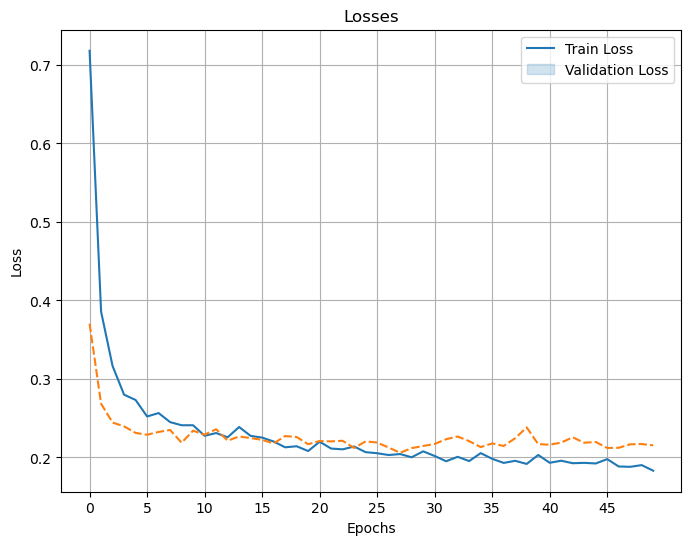

In [22]:
import torch
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from torch.utils.data import random_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import os 
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

torch.manual_seed(42)

def iterate(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for graph_data, cls_embed, mean_embed, il_type, labels in train_loader:
        graph_data = graph_data.to(device)
        cls_embed = cls_embed.to(device)
        mean_embed = mean_embed.to(device)
        il_type = il_type.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(graph_data, cls_embed, mean_embed, il_type)
        loss = criterion(outputs.view(-1), labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for graph_data, cls_embed, mean_embed, il_type, labels in val_loader:
            graph_data = graph_data.to(device)
            cls_embed = cls_embed.to(device)
            mean_embed = mean_embed.to(device)
            il_type = il_type.to(device)
            labels = labels.to(device)

            outputs = model(graph_data, cls_embed, mean_embed, il_type)
            loss = criterion(outputs.view(-1), labels.view(-1))
            total_loss += loss.item()

    return total_loss / len(val_loader)

def evaluate_regression(y_true, y_pred):
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()

    y_true = np.array(y_true, dtype=float).flatten()
    y_pred = np.array(y_pred, dtype=float).flatten()

    if np.any(np.isnan(y_true)) or np.any(np.isnan(y_pred)):
        raise ValueError("NaNs detected in y_true or y_pred!")
    if np.any(np.isinf(y_true)) or np.any(np.isinf(y_pred)):
        raise ValueError("Infs detected in y_true or y_pred!")
    assert y_true.shape == y_pred.shape, f"Shape mismatch: {y_true.shape} vs {y_pred.shape}"

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    spearman_r, _ = spearmanr(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Spearman rho: {spearman_r:.4f}")

    return f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nPearson r: {pearson_r:.4f}\nSpearman rho: {spearman_r:.4f}"

def make_plots(y_true, y_pred, run_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', lw=2)  # Line y=x
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predictions vs True Values")
    plt.savefig(f"results/predictions_{run_name}.png")
    plt.close()

    plt.figure(figsize=(8, 6))
    residuals = y_true.flatten() - y_pred.flatten()
    plt.scatter(y_pred.flatten(), residuals)
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Residuals vs Predicted Values")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.savefig(f"results/residuals_{run_name}.png")
    plt.close()


def main():
    results_path = "./results"
    model_dir = "./models"

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(results_path, exist_ok=True)
    dataset_path = "./ct.parquet"
    ct = pd.read_parquet(dataset_path)
    print("Dataset loaded\n")

    ct['X_cls'] = ct['X_cls'].apply(lambda x: np.array(x))
    ct['X_mean'] = ct['X_mean'].apply(lambda x: np.array(x))
       # Create dataset
    dataset = CTDataset(ct)

    # dataset used:
    df = ct
    run_name = "ct"

    # split the dataset
    train, test, val = random_split(
        dataset, 
        lengths=[0.75, 0.15, 0.1],
        generator=torch.Generator().manual_seed(42)
    )

    trainLoader = DataLoader(train, batch_size=32, shuffle=True)
    testLoader = DataLoader(test, batch_size=32, shuffle=False)
    valLoader = DataLoader(val, batch_size=32, shuffle=False)

    in_channels_cls = df['X_cls'].iloc[0].shape[0]
    in_channels_mean = df['X_mean'].iloc[0].shape[0]
    in_channels = dataset[0][0].x.shape[1]

    # ---------
    out_channels = 128
    hidden_dim = 128
    # ---------

    print(f"Input channels: {in_channels_cls}, {in_channels_mean}, {in_channels}")
    print(f"Output channels: {out_channels}")


    def train_model(trainLoader, valLoader, in_channels_cls, in_channels_mean, in_channels, out_channels, hidden_dim):
        
        print("Loaders created. Starting training...\n")
        model = twoTrackNetwork(
            in_channels=in_channels,
            in_channels_cls=in_channels_cls, 
            in_channels_mean=in_channels_mean,
            out_channels=out_channels, 
            hidden_dim=hidden_dim
        )
        print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

        optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay=1e-6)
        criterion = torch.nn.MSELoss()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        epochs = 50
        history = []
        for epoch in range(epochs):
            train_loss = iterate(model, trainLoader, optimizer, criterion, device)
            val_loss = evaluate(model, valLoader, criterion, device)

            losses = {
                'train_loss': train_loss,
                'val_loss': val_loss
            }
            print(f"epoch: {epoch}, train loss: {losses['train_loss'] :.3f}, val loss: {losses['val_loss'] :.3f}")
            history.append(losses)

        print("Training Complete")

        losses_df = pd.DataFrame(history)
        plt.figure(figsize=(8, 6))
        plt.title("Losses")
        sns.lineplot(losses_df)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend(['Train Loss', 'Validation Loss'])
        plt.xticks(range(0, epochs, 5))
        plt.grid()
        plt.savefig(f"results/losses_{run_name}.png")
        return history, model

    history, model = train_model(trainLoader, valLoader, in_channels_cls, in_channels_mean, in_channels, out_channels, hidden_dim) 

    # test the model on the test data:

    criterion = torch.nn.MSELoss()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    test_loss = evaluate(model, testLoader, criterion, device)
    print(f'Test loss: {test_loss}')
    y_true = []
    y_pred = []
    with torch.no_grad():
        for graph_data, cls_embed, mean_embed, il_type, labels in testLoader:
            graph_data = graph_data.to(device)
            cls_embed = cls_embed.to(device)
            mean_embed = mean_embed.to(device)
            labels = labels.to(device)
            il_type = il_type.to(device)

            outputs = model(graph_data, cls_embed, mean_embed, il_type)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print("Evaluation metrics:")
    output = evaluate_regression(y_true, y_pred)
    with open(f"results/perf_mets_{run_name}.txt", 'w+') as f:
        f.write(output)

    make_plots(y_true, y_pred, run_name)
    print("Plots saved as predictions.png and residuals.png")

    # Save the model
    torch.save(model.state_dict(), f"models/model_{run_name}.pth")
    print(f"Model saved as models/model_{run_name}.pth")

if __name__ == '__main__':
    main()

In [119]:
# cross-validation
from sklearn.model_selection import KFold
from torch.utils.data import Subset

k=10
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_losses = []
fold_r2 = []
batch_size = 32
dataset_path = "./ct.parquet"
ct = pd.read_parquet(dataset_path)
print("Dataset loaded\n")

ct['X_cls'] = ct['X_cls'].apply(lambda x: np.array(x))
ct['X_mean'] = ct['X_mean'].apply(lambda x: np.array(x))
# Create dataset
dataset = CTDataset(ct)

def test(testLoader, model):
    y_true = []
    y_pred = []
    with torch.no_grad():
        for graph_data, cls_embed, mean_embed, labels in testLoader:
            graph_data = graph_data.to(device)
            cls_embed = cls_embed.to(device)
            mean_embed = mean_embed.to(device)
            labels = labels.to(device)

            outputs = model(graph_data, cls_embed, mean_embed)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())

    return y_true, y_pred

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"\nFold {fold+1}/{k}")

    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    criterion = torch.nn.MSELoss()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    in_channels_cls = dataset[0][1].shape[0]
    in_channels_mean = dataset[0][2].shape[0]
    in_channels = dataset[0][0].x.shape[1]
    out_channels = 64

    model = twoTrackNetwork(
        in_channels=in_channels,
        in_channels_cls=in_channels_cls,
        in_channels_mean=in_channels_mean,
        out_channels=out_channels
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    val_losses = evaluate(model, val_loader, criterion, device)
    fold_losses.append(val_losses)
    y_true, y_pred = test(val_loader, model)
    r2 = r2_score(y_true, y_pred)
    fold_r2.append(r2)

    print(f"Fold {fold+1} Validation Loss: {val_losses[-1]:.4f}")
    fold_losses.append(val_losses[-1])

print("\nAverage Validation Loss:", np.mean(fold_losses))
print("Standard Deviation of Validation Loss:", np.std(fold_losses))

print("Average R2 Score:", np.mean(fold_r2))

Dataset loaded


Fold 1/10


TypeError: twoTrackNetwork.__init__() missing 1 required positional argument: 'hidden_dim'

In [167]:
# save the model
torch.save(model.state_dict(), "siamese_nn_model.pth")

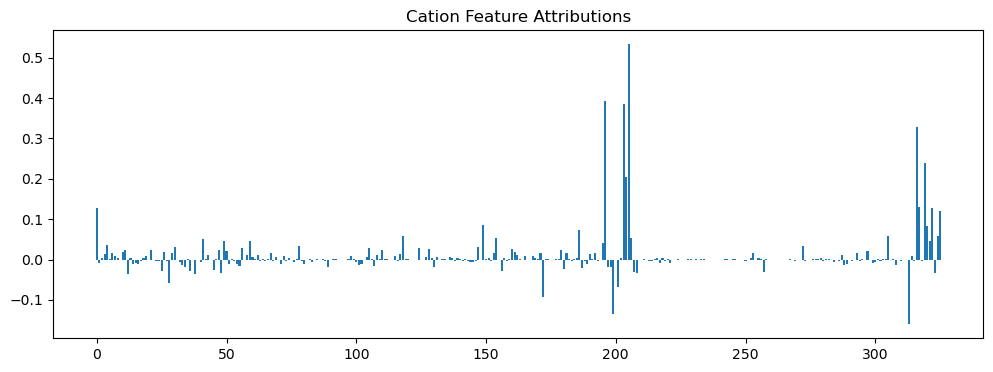

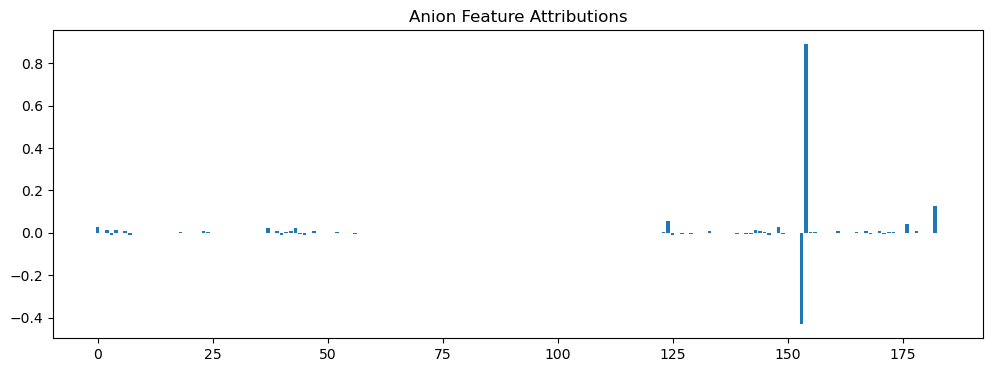

In [168]:
from captum.attr import IntegratedGradients

model.eval()
cation_batch, anion_batch, target_batch = next(iter(test_loader))
cation_batch, anion_batch = cation_batch.to(device), anion_batch.to(device)

def forward_func(cation_input, anion_input):
    return model(cation_input, anion_input)

ig = IntegratedGradients(model)
attributions = ig.attribute((cation_batch[:1], anion_batch[:1]), target=None, n_steps=50, return_convergence_delta=False)

cation_attributions, anion_attributions = attributions

cation_attr = cation_attributions.detach().cpu().numpy().flatten()
anion_attr = anion_attributions.detach().cpu().numpy().flatten()

cation_attr /= np.linalg.norm(cation_attr)
anion_attr /= np.linalg.norm(anion_attr)

plt.figure(figsize=(12,4))
plt.bar(range(len(cation_attr)), cation_attr)
plt.title("Cation Feature Attributions")
plt.show()

plt.figure(figsize=(12,4))
plt.bar(range(len(anion_attr)), anion_attr)
plt.title("Anion Feature Attributions")
plt.show()

In [172]:
# sort the cation_attr and check which ones are the most important
sorted_cation_indices = np.argsort(cation_attr)[::-1]

print("Most important cation features:")
for i in sorted_cation_indices[:10]:  # top 10 features
    print(f"Feature {i}: {cation_attr[i]}")

# same for anion
sorted_anion_indices = np.argsort(anion_attr)[::-1]

print("Most important anion features:")
for i in sorted_anion_indices[:10]:  # top 10 features
    print(f"Feature {i}: {anion_attr[i]}")

# names of the important features
feature_names = df.columns.tolist()
print("-"*25)
# map feature importances to their names
cation_feature_importances = {feature_names[i]: cation_attr[i] for i in sorted_cation_indices[:10]}
anion_feature_importances = {feature_names[i]: anion_attr[i] for i in sorted_anion_indices[:10]}

print("Most important cation features with names:")
for feature, importance in cation_feature_importances.items():
    print(f"Feature {feature}: {importance:.5f}")

print("-"*25)

print("Most important anion features with names:")
for feature, importance in anion_feature_importances.items():
    print(f"Feature {feature}: {importance :.5f}")   


Most important cation features:
Feature 205: 0.5332388877868652
Feature 196: 0.39262622594833374
Feature 203: 0.38568851351737976
Feature 316: 0.32788288593292236
Feature 319: 0.23800988495349884
Feature 204: 0.20503133535385132
Feature 317: 0.13136813044548035
Feature 0: 0.12702131271362305
Feature 322: 0.12688519060611725
Feature 325: 0.12027456611394882
Most important anion features:
Feature 154: 0.8883501887321472
Feature 182: 0.1261269748210907
Feature 124: 0.055709466338157654
Feature 176: 0.0420120432972908
Feature 0: 0.029527366161346436
Feature 148: 0.026555275544524193
Feature 43: 0.024493563920259476
Feature 37: 0.021309753879904747
Feature 143: 0.01377737708389759
Feature 2: 0.012229399755597115
-------------------------
Most important cation features with names:
Feature PCA_ecfp_a_35: 0.53324
Feature PCA_ecfp_a_26: 0.39263
Feature PCA_ecfp_a_33: 0.38569
Feature PCA_molecular_c_14: 0.32788
Feature PCA_molecular_a_0: 0.23801
Feature PCA_ecfp_a_34: 0.20503
Feature PCA_molecul